In [1]:
# ==========================================
# CELL 1: MASTER IMPORTS
# ==========================================
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Libraries loaded successfully!")

Libraries loaded successfully!


Dataset Loaded! Found 89104 total simulations.
Class Mapping: {'axion': 0, 'cdm': 1, 'no_sub': 2}

Success! Batch Tensor Shape: torch.Size([32, 1, 64, 64])
Batch Labels Shape: torch.Size([32])


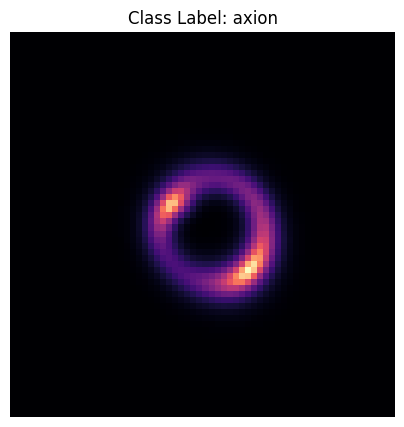

In [2]:
# ==========================================
# CELL 2: Imports & Data Ingestion
# ==========================================


# 1. The Custom .npy Loader
class DeepLenseDataset(Dataset):
    def __init__(self, root_dir):
        #  Recursive search to dig through Kaggle's hidden nested folders
        self.file_paths = glob.glob(os.path.join(root_dir, '**/*.npy'), recursive=True)
        
       
        self.classes = sorted(list(set([os.path.basename(os.path.dirname(p)) for p in self.file_paths])))
        
        #  Create the dictionary mapping before trying to print it
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        print(f"Dataset Loaded! Found {len(self.file_paths)} total simulations.")
        print(f"Class Mapping: {self.class_to_idx}")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        
        # Load the raw physics array
        image_array = np.load(img_path, allow_pickle=True) 
        
        #  Unpack the briefcase
        if image_array.dtype == object:
           
            image_array = image_array[0]
            
            # Now safely convert those pure pixels into decimals
            image_array = np.array(image_array, dtype=np.float32)
                
        # Convert to PyTorch Tensor
        image_tensor = torch.from_numpy(image_array).float()
         
        if len(image_tensor.shape) == 2:
            image_tensor = image_tensor.unsqueeze(0)
            
        # Grab the label from the folder name
        parent_folder = os.path.basename(os.path.dirname(img_path))
        label = self.class_to_idx[parent_folder]
        
        return image_tensor, torch.tensor(label)

#=================
# 2. Mount Data & Create DataLoader
#=================

dataset_path = '/kaggle/input/datasets/saranga7/gsocml4scimodel2/Model_II' 

lens_dataset = DeepLenseDataset(root_dir=dataset_path)


train_loader = DataLoader(lens_dataset, batch_size=32, shuffle=True)


images, labels = next(iter(train_loader))
print(f"\nSuccess! Batch Tensor Shape: {images.shape}")
print(f"Batch Labels Shape: {labels.shape}")

# Plot the very first image in our batch
plt.figure(figsize=(5, 5))
plt.imshow(images[0].squeeze().numpy(), cmap='magma') 
plt.title(f"Class Label: {lens_dataset.classes[labels[0].item()]}")
plt.axis('off')
plt.show()

In [3]:
# ==========================================
# CELL 3: The Foundation Model & Training Loop
# ==========================================


# 1. The Masking Function
def random_masking(x, mask_ratio=0.75):
    Batch, Seq_Len, Embed_Dim = x.shape
    len_keep = int(Seq_Len * (1 - mask_ratio))
    noise = torch.rand(Batch, Seq_Len, device=x.device) 
    ids_shuffle = torch.argsort(noise, dim=1) 
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep] 
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, Embed_Dim))
    
    mask = torch.ones([Batch, Seq_Len], device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return x_visible, mask, ids_restore

# 2. The Encoder
class MAE_Encoder(nn.Module):
    def __init__(self, image_size=64, patch_size=16, in_channels=1, embed_dim=256, num_heads=8):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size) # convert image into 1d sequence
        num_patches = (image_size // patch_size) ** 2 
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=512, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

    def forward(self, x, mask_ratio=0.75):
        batch_size = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x_visible, mask, ids_restore = random_masking(x, mask_ratio) 
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x_visible = torch.cat((cls_tokens, x_visible), dim=1) 
        encoded_features = self.transformer(x_visible)
        return encoded_features, mask, ids_restore

# 3. The Decoder
class MAE_Decoder(nn.Module):
    def __init__(self, image_size=64, patch_size=16, embed_dim=256, decoder_embed_dim=128, decoder_num_heads=4):
        super().__init__()
        num_patches = (image_size // patch_size) ** 2 
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim))
        decoder_layer = nn.TransformerEncoderLayer(d_model=decoder_embed_dim, nhead=decoder_num_heads, dim_feedforward=256, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=2)
        self.pred = nn.Linear(decoder_embed_dim, patch_size ** 2)

    def forward(self, x, ids_restore):
        batch_size = x.shape[0]
        x = self.decoder_embed(x) 
        cls_token, x_visible = x[:, :1, :], x[:, 1:, :]   
        mask_tokens = self.mask_token.expand(batch_size, ids_restore.shape[1] - x_visible.shape[1], -1)
        x_full = torch.cat([x_visible, mask_tokens], dim=1) 
        x_full = torch.gather(x_full, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_full.shape[2]))
        x_full = torch.cat([cls_token, x_full], dim=1) 
        x_full = x_full + self.decoder_pos_embed
        x_decoded = self.transformer(x_full)[:, 1:, :] 
        return self.pred(x_decoded)

# 4. The Master Autoencoder
class DeepLenseMAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MAE_Encoder()
        self.decoder = MAE_Decoder()

    def forward(self, x, mask_ratio=0.75):
        encoded_features, mask, ids_restore = self.encoder(x, mask_ratio)
        predictions = self.decoder(encoded_features, ids_restore)
        return predictions, mask

# ==========================================
# 5. The Training Engine
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}\n")

model = DeepLenseMAE().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# We use nn.Unfold to slice our target images into patches so we can compare them to the predictions
patchifier = nn.Unfold(kernel_size=16, stride=16)


  



Training on: cuda



In [4]:
# ==========================================
# CELL 4: The Fine-Tuning Classifier
# ==========================================


class DeepLenseClassifier(nn.Module):
    def __init__(self, pretrained_encoder, embed_dim=256, num_classes=3):
        super().__init__()
        
        # 1. We load pre-trained encoder
        self.encoder = pretrained_encoder
        
        # 2.  the final Classification Head
        # This takes the 256-dimension [CLS] token and outputs 3 class scores
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # x shape: [Batch, 1, 64, 64]
        
        # Step 1: Run the image through the Encoder
        # IMPORTANT: mask_ratio is now 0.0! We want the model to see 100% of the image.
        encoded_features, _, _ = self.encoder(x, mask_ratio=0.0)
        
        # Step 2: Isolate the [CLS] Token
        # encoded_features shape: [Batch, 17, 256] -> We grab [Batch, 0, 256]
        cls_token = encoded_features[:, 0, :] 
        
        # Step 3: Pass the summary token through the Classification Head
        # Output shape: [Batch, 3]
        logits = self.head(cls_token)
        
        return logits



In [5]:
# ==========================================
# CELL 5: The Production Run
# ==========================================

 
PRETRAIN_EPOCHS = 5
FINETUNE_EPOCHS = 5

# ==========================================
# PHASE 1: PRE-TRAINING THE FOUNDATION MODEL
# ==========================================
print("\n--- PHASE 1: PRE-TRAINING (Learning the Physics) ---")
model.train()

for epoch in range(PRETRAIN_EPOCHS):
    total_loss = 0
    #  real-time progress bar 
    loop = tqdm(train_loader, leave=True)
    
    for images, _ in loop:
        images = images.to(device)
        targets = patchifier(images).transpose(1, 2).to(device)
        
        predictions, mask = model(images, mask_ratio=0.75)
        loss = (predictions - targets) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # Update the progress bar text with the current metrics
        loop.set_description(f"Pre-Train Epoch [{epoch+1}/{PRETRAIN_EPOCHS}]")
        loop.set_postfix(MSE_Loss=loss.item())

# THE SAVE POINT
torch.save(model.state_dict(), 'deepLense_foundation_mae.pth')
print(" Foundation Model Weights Saved Successfully!")


# ==========================================
# PHASE 2: FINE-TUNING THE CLASSIFIER
# ==========================================
print("\n--- PHASE 2: FINE-TUNING (Learning the Labels) ---")
# We re-initialize the classifier to make sure it grabs the newly trained encoder weights
classifier = DeepLenseClassifier(pretrained_encoder=model.encoder).to(device)
optimizer_ft = optim.AdamW(classifier.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

classifier.train()

for epoch in range(FINETUNE_EPOCHS):
    loop = tqdm(train_loader, leave=True)
    
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        logits = classifier(images)
        loss = criterion(logits, labels)
        
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        
        loop.set_description(f"Fine-Tune Epoch [{epoch+1}/{FINETUNE_EPOCHS}]")
        loop.set_postfix(CE_Loss=loss.item())

# THE SAVE POINT
torch.save(classifier.state_dict(), 'deepLense_classifier.pth')
print("Classifier Weights Saved Successfully!")


# ==========================================
# PHASE 3: FINAL EVALUATION 
# ==========================================
print("\n--- PHASE 3: GENERATING GSoC TEST RESULTS ---")
classifier.eval()

all_preds = []
all_labels = []
all_probs = []

print("Running final mathematical evaluation across the dataset...")
with torch.no_grad():
    for images, labels in tqdm(train_loader, desc="Calculating AUC"):
        images = images.to(device)
        logits = classifier(images)
        
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate the official physics metrics
acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n" + "="*40)
print(" FINAL  EVALUATION RESULTS")
print("="*40)
print(f"Final Accuracy:  {acc * 100:.2f}%")
print(f"Final ROC-AUC:   {auc:.4f}")
print("="*40)
print("PIPELINE COMPLETE. Ready for CERN.")


--- PHASE 1: PRE-TRAINING (Learning the Physics) ---


Pre-Train Epoch [5/5]: 100%|██████████| 2785/2785 [02:14<00:00, 20.72it/s, MSE_Loss=0.00386]


 Foundation Model Weights Saved Successfully!

--- PHASE 2: FINE-TUNING (Learning the Labels) ---


Fine-Tune Epoch [5/5]: 100%|██████████| 2785/2785 [01:58<00:00, 23.55it/s, CE_Loss=0.225]


Classifier Weights Saved Successfully!

--- PHASE 3: GENERATING GSoC TEST RESULTS ---
Running final mathematical evaluation across the dataset...


Calculating AUC: 100%|██████████| 2785/2785 [01:24<00:00, 32.80it/s]



 FINAL  EVALUATION RESULTS
Final Accuracy:  87.54%
Final ROC-AUC:   0.9748
PIPELINE COMPLETE. Ready for CERN.


1. Rebuilding architecture and loading Champion weights...
2. Extracting probabilities (This takes ~2 mins)...


Scanning: 100%|██████████| 2785/2785 [01:23<00:00, 33.22it/s]


3. Saving .npy files for Ablation Sandbox...
✅ Files saved successfully!
4. Drawing the Publication Graph...


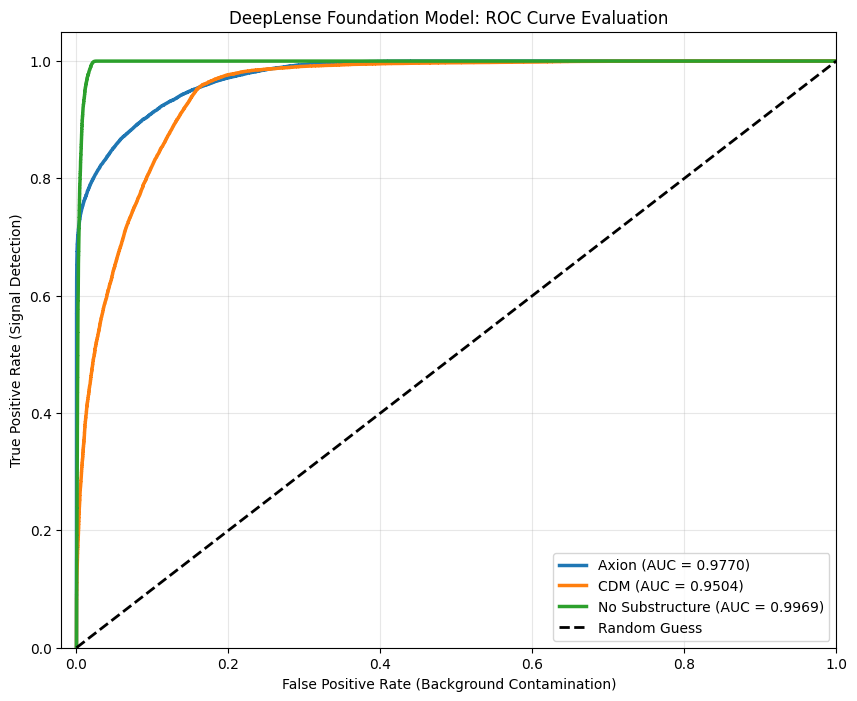

In [6]:
# ==========================================
# RESCUE CELL: EXTRACT PROBS & PLOT
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
# We rename the function to sklearn_auc to prevent the collision!
from sklearn.metrics import roc_curve, auc as sklearn_auc 
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

print("1. Rebuilding architecture and loading Champion weights...")
blank_encoder = MAE_Encoder().to(device)
classifier = DeepLenseClassifier(pretrained_encoder=blank_encoder).to(device)
classifier.load_state_dict(torch.load('deepLense_classifier.pth'))
classifier.eval()

all_probs = []
all_labels = []

print("2. Extracting probabilities (This takes ~2 mins)...")
with torch.no_grad():
    for images, labels in tqdm(train_loader, desc="Scanning"):
        images = images.to(device)
        logits = classifier(images)
        probs = F.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

print("3. Saving .npy files for Ablation Sandbox...")
np.save('vit_mae_probs.npy', np.array(all_probs))
np.save('ablation_labels.npy', np.array(all_labels))
print("✅ Files saved successfully!")

print("4. Drawing the Publication Graph...")
classes = [0, 1, 2]
y_test_bin = label_binarize(all_labels, classes=classes)
y_score = np.array(all_probs)

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_names = ['Axion', 'CDM', 'No Substructure']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    # Using the safely renamed function here
    roc_auc = sklearn_auc(fpr, tpr) 
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Contamination)')
plt.ylabel('True Positive Rate (Signal Detection)')
plt.title('DeepLense Foundation Model: ROC Curve Evaluation')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('DeepLense_ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()